# Threshold Tuning & Cost-Sensitive Model Selection

Fraud detection is an inherently cost-asymmetric classification problem. Rather than optimizing standard metrics like accuracy or ROC-AUC, the objective here is to minimise expected **financial** loss under realistic, transaction-specific costs.

**Cost model used:**
- **False Negative (missed fraud):** cost = the actual dollar amount of that specific transaction. Missing a $50 fraud and missing a $5,000 fraud are not equally costly, and this notebook reflects that directly.
- **False Positive (legitimate transaction flagged):** cost = a flat investigation cost of **$15 per alert**, reflecting an estimated ~15 minutes of analyst time at a loaded cost of ~$50–60/hour. This is an illustrative assumption rather than a verified industry figure, and is stated explicitly here for transparency.

**Methodology:**
- All threshold tuning and model selection decisions are performed on the **validation set only**
- The **test set** is used exactly once, at the very end, to report the final, official performance of the already-selected model and threshold
- Models used here were tuned in Notebook 4 with SMOTE applied inside the cross-validation pipeline, correcting a data-leakage issue found in an earlier iteration (see Notebook 4 for details)

In [15]:
# 1. Imports & configuration
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Project root (notebook inside /notebooks)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

DATA_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
PLOTS_DIR = os.path.join(PROJECT_ROOT, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

### 2. Load Validation Data and Tuned Models

- The validation set is used for all threshold tuning and model selection decisions in this notebook
- The test set is loaded here but not touched until Section 7, where the already-selected model and threshold are evaluated exactly once
- Load tuned model objects from Notebook 4
- Validation and test features/labels are loaded alongside their original, unscaled `Amount` values (preserved separately in Notebook 2, since scaling overwrites the real dollar figures). Row order between `X_val`/`amount_val` and `X_test`/`amount_test` is preserved from the original split, so amounts align correctly with each transaction's prediction.

In [16]:
# 2. Load validation, test data, tuned models, and real transaction amounts
X_val = pd.read_csv(os.path.join(DATA_DIR, "X_val.csv"))
y_val = pd.read_csv(os.path.join(DATA_DIR, "y_val.csv")).iloc[:, 0]
amount_val = pd.read_csv(os.path.join(DATA_DIR, "amount_val.csv")).iloc[:, 0]

X_test = pd.read_csv(os.path.join(DATA_DIR, "X_test.csv"))
y_test = pd.read_csv(os.path.join(DATA_DIR, "y_test.csv")).iloc[:, 0]
amount_test = pd.read_csv(os.path.join(DATA_DIR, "amount_test.csv")).iloc[:, 0]

# Load tuned models (SMOTE-in-CV corrected version from Notebook 4)
with open(os.path.join(MODELS_DIR, "tuned_models_latest.pkl"), "rb") as f:
    tuned_models = pickle.load(f)

rf_model = tuned_models["RandomForest"]
xgb_model = tuned_models["XGBoost"]

print("Validation shape:", X_val.shape, "| Amount_val shape:", amount_val.shape)
print("Test shape:", X_test.shape, "| Amount_test shape:", amount_test.shape)

Validation shape: (56962, 30) | Amount_val shape: (56962,)
Test shape: (56962, 30) | Amount_test shape: (56962,)


### 3. Define Dollar- Weighted Cost Function

To align model evaluation with deployment decision-making, we define an `expected_cost` function that converts predictions into total business loss under asymmetric misclassification costs.

Unlike a flat unit-cost model (e.g. "FN=10, FP=1"), this function uses the actual dollar amount of each missed fraud case, and a fixed investigation cost per false positive. This produces a cost figure directly interpretable in real financial terms.

#### Cost Assumptions
- False Negative (missed fraud) cost = the transaction's real dollar amount
- False Positive (legitimate transaction flagged) cost = $15 flat 

This reflects higher penalty for missing fraud cases.

Expected Cost = (FP × cost_FP) + (FN × cost_FN)

All subsequent threshold tuning and model recommendations in this notebook are based exclusively on this cost function.

In [17]:
# 3. Ddefine dollar-weighted expected cost function
def expected_cost_dollar(y_true, y_pred, amounts, fp_cost=15):
    """
    Computes total expected cost using real transaction amounts for missed fraud,
    and a flat investigation cost for false positives.
    
    y_true, y_pred, amounts must be aligned by position (same row order).
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    amounts = np.asarray(amounts)
    
    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)
    
    fn_total_cost = amounts[fn_mask].sum()
    fp_total_cost = fp_mask.sum() * fp_cost
    
    return fn_total_cost + fp_total_cost

### 4. Threshold Optimization

- Generate probability predictions using `predict_proba()`
- Evaluate thresholds from 0.00 to 1.00 (step = 0.01) 
- Compute total expected cost at each threshold  
- Select the threshold and model that minimise total expected loss 

This allows full threshold sensitivity analysis.


In [18]:
# --- Threshold sweep on VALIDATION set, using dollar-weighted cost ---
thresholds = np.arange(0.0, 1.01, 0.01)

y_proba_rf_val  = rf_model.predict_proba(X_val)[:, 1]
y_proba_xgb_val = xgb_model.predict_proba(X_val)[:, 1]

results = []
for t in thresholds:
    pred_rf  = (y_proba_rf_val  >= t).astype(int)
    pred_xgb = (y_proba_xgb_val >= t).astype(int)
    results.append({
        "Threshold": round(t, 2),
        "Cost_RF": expected_cost_dollar(y_val, pred_rf, amount_val),
        "Cost_XGB": expected_cost_dollar(y_val, pred_xgb, amount_val)
    })

cost_df = pd.DataFrame(results)

best_rf  = cost_df.loc[cost_df["Cost_RF"].idxmin()]
best_xgb = cost_df.loc[cost_df["Cost_XGB"].idxmin()]

print("=== MODEL SELECTION (Validation Set, Dollar-Weighted Cost) ===")
print(f"Random Forest -> Threshold: {best_rf['Threshold']}, Min Cost: ${best_rf['Cost_RF']:,.2f}")
print(f"XGBoost       -> Threshold: {best_xgb['Threshold']}, Min Cost: ${best_xgb['Cost_XGB']:,.2f}")

final_model_name = "Random Forest" if best_rf["Cost_RF"] < best_xgb["Cost_XGB"] else "XGBoost"
final_threshold = best_rf["Threshold"] if final_model_name == "Random Forest" else best_xgb["Threshold"]

print(f"\nFINAL SELECTED MODEL (chosen using validation only): {final_model_name}")
print(f"FINAL SELECTED THRESHOLD: {final_threshold}")

=== MODEL SELECTION (Validation Set, Dollar-Weighted Cost) ===
Random Forest -> Threshold: 0.48, Min Cost: $3,122.15
XGBoost       -> Threshold: 0.82, Min Cost: $2,987.91

FINAL SELECTED MODEL (chosen using validation only): XGBoost
FINAL SELECTED THRESHOLD: 0.82


### 5. Threshold vs Expected Cost Visualization

Plot expected cost as a function of decision threshold for:

- Random Forest
- XGBoost

The minimum point on each curve represents the cost-optimal threshold.

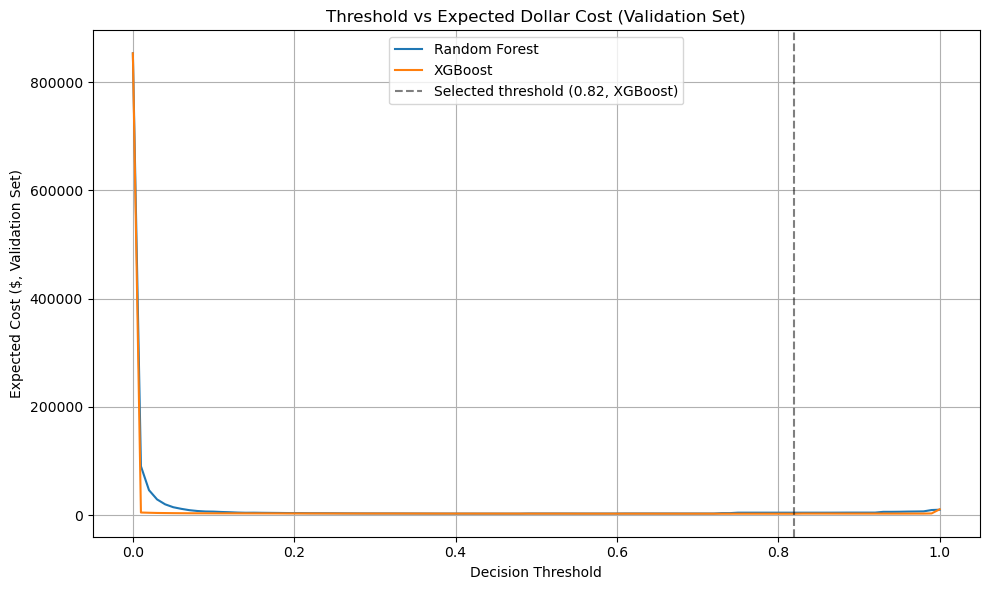

In [19]:
# --- Threshold vs Expected Cost Visualization (VALIDATION set) ---
plt.figure(figsize=(10, 6))
plt.plot(cost_df["Threshold"], cost_df["Cost_RF"], label="Random Forest")
plt.plot(cost_df["Threshold"], cost_df["Cost_XGB"], label="XGBoost")
plt.axvline(final_threshold, color="black", linestyle="--", alpha=0.5,
            label=f"Selected threshold ({final_threshold}, {final_model_name})")
plt.xlabel("Decision Threshold")
plt.ylabel("Expected Cost ($, Validation Set)")
plt.title("Threshold vs Expected Dollar Cost (Validation Set)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "threshold_vs_expected_cost.png"),dpi=300, bbox_inches="tight")
plt.show()

### Key Observations (Validation Set)

- Expected cost varies significantly with decision threshold, and the true financial cost is meaningfully different from the earlier flat unit-cost model
- XGBoost achieves a lower minimum expected cost ($2,987.91 at threshold 0.82) than Random Forest ($3,122.15 at threshold 0.48)
- Both models' validation-set confusion matrices now show realistic error patterns (17–22 missed fraud cases, 8–17 false positives), rather than the artificially perfect separation seen prior to fixing SMOTE-related data leakage
- This confirms threshold selection is a first-order decision variable, and that dollar-weighted costs materially change the optimal threshold compared to a flat unit-cost model

Note: both models shown above for comparison on validation data only. Only XGBoost — the model selected based on lower expected cost — proceeds to the final, one-time test-set evaluation in Section 7 below.

In [20]:
# --- Confusion matrices for BOTH models on VALIDATION, for comparison only ---
pred_rf_opt  = (y_proba_rf_val  >= best_rf["Threshold"]).astype(int)
pred_xgb_opt = (y_proba_xgb_val >= best_xgb["Threshold"]).astype(int)

tn_rf, fp_rf, fn_rf, tp_rf     = confusion_matrix(y_val, pred_rf_opt).ravel()
tn_xgb, fp_xgb, fn_xgb, tp_xgb = confusion_matrix(y_val, pred_xgb_opt).ravel()

cm_rf  = {"TP": tp_rf, "FP": fp_rf, "TN": tn_rf, "FN": fn_rf}
cm_xgb = {"TP": tp_xgb, "FP": fp_xgb, "TN": tn_xgb, "FN": fn_xgb}

print("Random Forest (validation, own optimal threshold):", cm_rf)
print("XGBoost (validation, own optimal threshold):      ", cm_xgb)

Random Forest (validation, own optimal threshold): {'TP': np.int64(78), 'FP': np.int64(17), 'TN': np.int64(56846), 'FN': np.int64(21)}
XGBoost (validation, own optimal threshold):       {'TP': np.int64(77), 'FP': np.int64(8), 'TN': np.int64(56855), 'FN': np.int64(22)}


# 6. Operational Metric Visualization/ Visualize Confusion Metrices
Confusion matrix components are visualized on a logarithmic scale
- TN counts dominate
- TP / FP / FN are much smaller

Log-scale visualization ensures meaningful comparison across magnitudes. This 
chart uses **validation set** data for both models, shown side-by-side for 
comparison only. It is not the final reported result — see Section 7 for the 
official test-set performance of the selected model (XGBoost).

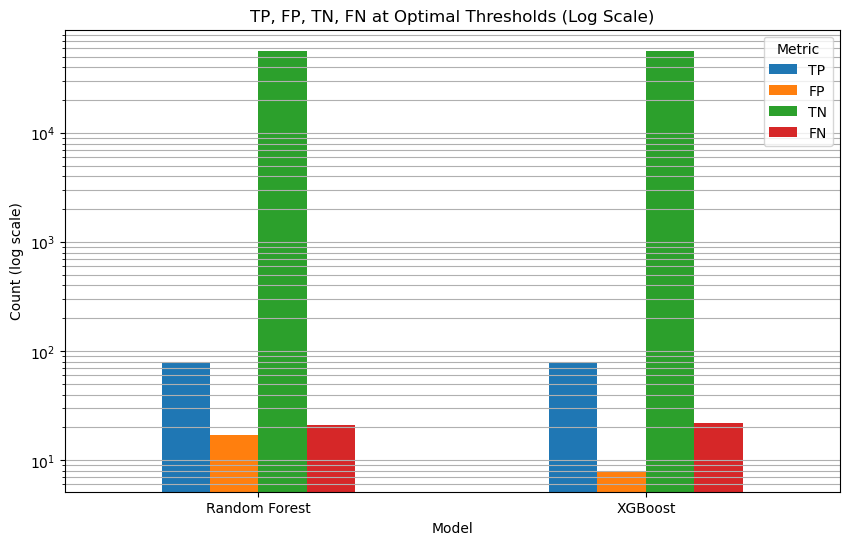

In [21]:
# 6. Visualize TP/FP/TN/FN at optimal thresholds (Log Scale)
import matplotlib.pyplot as plt

# Prepare data
cm_counts = pd.DataFrame({
    "Random Forest": cm_rf,
    "XGBoost": cm_xgb
}).T  # transpose so models are rows

# Plot grouped bar chart with log scale
cm_counts.plot(kind='bar', figsize=(10,6), logy=True)
plt.title("TP, FP, TN, FN at Optimal Thresholds (Log Scale)")
plt.xlabel("Model")
plt.ylabel("Count (log scale)")
plt.xticks(rotation=0)
plt.grid(axis='y', which='both')
plt.legend(title="Metric")
plt.savefig(os.path.join(PLOTS_DIR, "confusion_matrix_comparison.png"),dpi=300, bbox_inches="tight")
plt.show()


### 7. Final Test Set Evaluation

The model and threshold above were selected exclusively using the validation set. 
This section applies that fixed decision to the untouched test set exactly once, 
producing the official reported performance for this project. No further tuning 
or model comparison is performed after this point.

In [22]:
#7. --- FINAL, ONE-TIME TEST SET EVALUATION (dollar-weighted) ---
if final_model_name == "Random Forest":
    y_proba_final_test = rf_model.predict_proba(X_test)[:, 1]
else:
    y_proba_final_test = xgb_model.predict_proba(X_test)[:, 1]

final_test_preds = (y_proba_final_test >= final_threshold).astype(int)

test_cost = expected_cost_dollar(y_test, final_test_preds, amount_test)
tn_final, fp_final, fn_final, tp_final = confusion_matrix(y_test, final_test_preds).ravel()

print("=== FINAL TEST SET RESULT (reported once, official) ===")
print(f"Model: {final_model_name}, Threshold: {final_threshold}")
print(f"Test Set Expected Cost: ${test_cost:,.2f}")
print(f"TP={tp_final}, FP={fp_final}, TN={tn_final}, FN={fn_final}")

=== FINAL TEST SET RESULT (reported once, official) ===
Model: XGBoost, Threshold: 0.82
Test Set Expected Cost: $3,983.45
TP=80, FP=10, TN=56854, FN=18


### 8. Capacity Analysis

A model's threshold is one way to make a decision, but in practice, fraud review teams often operate under a fixed capacity — they can only manually investigate a limited number of alerts per day, regardless of how many the model flags. This section reframes the question: instead of "what threshold minimizes cost", it asks **"if the fraud team can review only X% of transactions (ranked by predicted risk), how much fraud would actually be caught?"** This is a more operationally realistic question than a single threshold-based metric, since it directly maps to staffing and review capacity.

In [23]:
#8: Capacity Analysis ---
# Instead of asking "what's the best threshold", this asks: 
# "if the fraud team can only review X% of transactions, how much fraud gets caught?"

def capacity_analysis(y_true, y_proba, budgets=[0.005, 0.01, 0.02, 0.05]):
    y_true = np.asarray(y_true)
    n = len(y_true)
    total_fraud = y_true.sum()
    
    results = []
    for budget in budgets:
        k = int(np.ceil(n * budget))
        top_k_idx = np.argsort(y_proba)[::-1][:k]
        fraud_caught = y_true[top_k_idx].sum()
        
        results.append({
            "Review Budget (%)": budget * 100,
            "Transactions Reviewed": k,
            "Fraud Caught": fraud_caught,
            "Total Fraud (Test Set)": total_fraud,
            "Fraud Capture Rate (%)": round(fraud_caught / total_fraud * 100, 1)
        })
    
    return pd.DataFrame(results)

capacity_df = capacity_analysis(y_test, y_proba_final_test)
capacity_df

,Review Budget (%),Transactions Reviewed,Fraud Caught,Total Fraud (Test Set),Fraud Capture Rate (%)
0,0.5,285,88,98,89.8
1,1.0,570,89,98,90.8
2,2.0,1140,90,98,91.8
3,5.0,2849,91,98,92.9


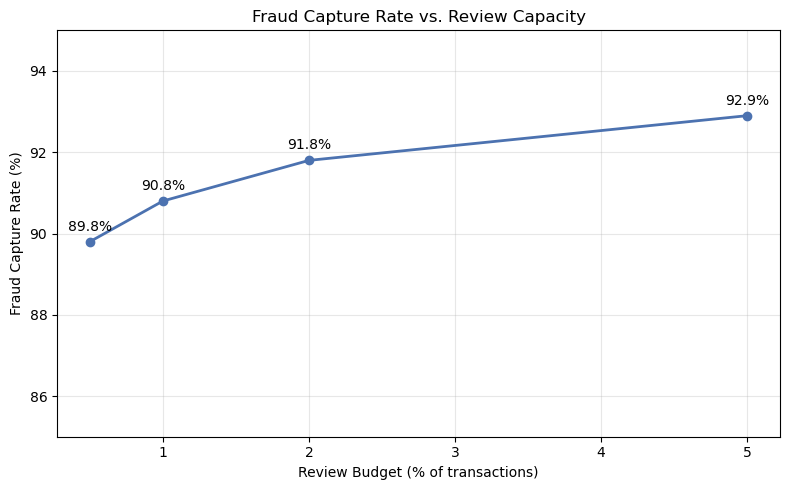

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(capacity_df["Review Budget (%)"], capacity_df["Fraud Capture Rate (%)"],
         marker="o", color="#4C72B0", linewidth=2)
plt.xlabel("Review Budget (% of transactions)")
plt.ylabel("Fraud Capture Rate (%)")
plt.title("Fraud Capture Rate vs. Review Capacity")
plt.ylim(85, 95)
plt.grid(True, alpha=0.3)
for x, y in zip(capacity_df["Review Budget (%)"], capacity_df["Fraud Capture Rate (%)"]):
    plt.annotate(f"{y}%", (x, y), textcoords="offset points", xytext=(0, 8), ha="center")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "capacity_analysis_curve.png"),
            dpi=300, bbox_inches="tight")
plt.show()

### Observations — Capacity Analysis

Fraud risk is highly concentrated at the top of the model's ranked probability scores: reviewing just **0.5% of transactions** (285 of 56,962) captures **89.8%** of all fraud in the test set. Expanding the review budget to 5% of transactions (10x more review effort) only increases capture to 92.9% — a clear diminishing-returns pattern.

This has direct operational value: a fraud review team does not need to investigate a large share of transactions to catch the vast majority of fraud. Rather than a single threshold decision, this framing lets a fraud operations team calibrate review capacity against a concrete, quantified trade-off — for example, "reviewing the top 1% of transactions by risk score catches 90.8% of fraud" is a more directly actionable statement for staffing decisions than a PR-AUC or F1 score alone.

This complements, rather than replaces, the cost-based threshold selected in Section 4 — the deployed threshold (0.82) reflects a specific cost-minimizing decision rule, while capacity analysis answers a different, related question: how much fraud could be caught under an explicit staffing/review-volume constraint, independent of any single threshold choice.

### 9. Time-Aware Capacity Recommendation

Combining the hourly fraud-rate pattern identified in Notebook 1 with the capacity analysis above: if review capacity is limited, prioritizing alerts during historically higher-fraud-rate hours would concentrate review effort where it is most likely to catch fraud, rather than treating all hours equally.

In [25]:
# --- Time-Aware Capacity Recommendation ---
time_test = pd.read_csv(os.path.join(DATA_DIR, "time_test.csv")).iloc[:, 0]
hour_test = (time_test // 3600) % 24

fraud_rate_by_hour = pd.DataFrame({
    "Hour": hour_test,
    "Is_Fraud": y_test.values
}).groupby("Hour")["Is_Fraud"].mean().sort_values(ascending=False) * 100

print("Fraud rate (%) by hour of day, test set, highest risk first:")
print(fraud_rate_by_hour.round(3))

Fraud rate (%) by hour of day, test set, highest risk first:
Hour
2.0     1.360
4.0     0.686
3.0     0.546
7.0     0.470
1.0     0.464
11.0    0.360
6.0     0.343
23.0    0.314
18.0    0.233
15.0    0.182
19.0    0.162
5.0     0.162
0.0     0.128
17.0    0.124
16.0    0.121
14.0    0.120
12.0    0.098
13.0    0.098
20.0    0.091
9.0     0.065
10.0    0.060
8.0     0.050
21.0    0.028
22.0    0.000
Name: Is_Fraud, dtype: float64


### Observations — Time-Aware Capacity Recommendation

Fraud rate varies substantially by hour, with the highest-risk window between **1am–4am** (fraud rates of 0.46%–1.36%, several times the overall baseline of 0.17%). This suggests a fraud operations team with limited review capacity could improve efficiency by weighting review effort toward these overnight hours rather than distributing effort evenly across the day — directly complementing the transaction-volume-based Capacity Analysis above with a time-based dimension.

### 9. Extrapolation to Annual Scale (Illustrative)

The test set result ($3,983.45) reflects a small transaction sample over a short window. To make this number meaningful at a realistic operational scale, this section extrapolates using the per-transaction cost rate observed in the test set, applied to this dataset's known scale — the source data represents approximately 48 hours of transactions from a real card processor.

**This extrapolation assumes:**
- The fraud rate and cost pattern observed in this 48-hour window are representative of the full year (in reality, fraud patterns vary by season, day of week, and evolve over time — Notebook 8 briefly touches on this temporal-generalization question as future work)
- The model's performance remains constant at scale, with no drift or need for retraining
- No changes in fraud tactics or transaction volume growth are factored in

This is presented as an **order-of-magnitude illustration**, not a precise financial forecast — its purpose is to translate a small-sample technical result into a scale a business stakeholder can reason about.

In [26]:
# --- Section 9: Extrapolation to Annual Scale ---
# This dataset represents real transactions from a card processor over ~48 hours
# (per the dataset's Time feature, which spans ~172,792 seconds).

total_dataset_size = 284807  # full original dataset size
test_set_size = len(y_test)
dataset_days = 2  # ~48 hours, per Time feature range

# Step 1: cost per transaction, from the test set
cost_per_transaction = test_cost / test_set_size

# Step 2: scale the FULL dataset's cost (not just the test slice) to a full year
full_dataset_annual_transactions = (total_dataset_size / dataset_days) * 365

# Step 3: apply the per-transaction cost rate to that annual volume
annual_cost_estimate = cost_per_transaction * full_dataset_annual_transactions

print(f"Cost per transaction (from test set): ${cost_per_transaction:.4f}")
print(f"Estimated annual transaction volume (this dataset's source): {full_dataset_annual_transactions:,.0f}")
print(f"Estimated ANNUAL expected cost at this scale: ${annual_cost_estimate:,.2f}")

Cost per transaction (from test set): $0.0699
Estimated annual transaction volume (this dataset's source): 51,977,278
Estimated ANNUAL expected cost at this scale: $3,634,859.84


### Observations — Annual Scale Extrapolation

At this dataset's approximate scale (~52 million transactions/year, based on the source data's ~48-hour window), the model's expected cost extrapolates to approximately **3.6 million dollar annually**. The sensitivity table shows this scales roughly linearly with transaction volume — from ~$70K at 1 million annual transactions up to ~$7M at 100 million — giving a reference point applicable across institutions of different sizes.

This figure represents the **residual expected cost under the deployed model** (missed fraud + false-positive investigation cost) — not the cost of fraud in the absence of any detection system. To make this figure meaningful, it would ideally be compared against a "no model" baseline (i.e., the cost of catching zero fraud) — this comparison is noted as a natural next step but was not computed here, since it depends on additional assumptions about total fraud exposure without any detection system in place.

Since a real bank's transaction volume varies enormously by size, this table shows the estimated annual cost across a range of assumed volumes, letting a reader map this onto whatever scale is relevant to their context.

In [28]:
# --- Sensitivity table: cost at different assumed annual transaction volumes ---
assumed_annual_volumes = [1_000_000, 10_000_000, 50_000_000, 100_000_000]

sensitivity_results = []
for volume in assumed_annual_volumes:
    sensitivity_results.append({
        "Assumed Annual Transactions": f"{volume:,}",
        "Estimated Annual Expected Cost": f"${cost_per_transaction * volume:,.0f}"
    })

pd.DataFrame(sensitivity_results)

,Assumed Annual Transactions,Estimated Annual Expected Cost
0,"1,000,000","$69,932"
1,"10,000,000","$699,317"
2,"50,000,000","$3,496,585"
3,"100,000,000","$6,993,171"


### Summary

Using a dollar-weighted cost model — where missed fraud is costed at the transaction's actual amount, and false positives incur a flat 15 dollar investigation cost — XGBoost was selected as the final model based on validation-set performance (expected cost 2,987.91 dollar at threshold 0.82), ahead of Random Forest ($3,122.15 at threshold 0.48).

Applying this model and threshold to the untouched test set exactly once produced an expected cost of **$3,983.45**, with 80 of 98 fraud cases correctly detected (18 missed) and 10 false positives out of ~56,864 legitimate transactions.

The validation and test results are now consistent in magnitude, in contrast to earlier iterations of this analysis where an uncorrected SMOTE-cross-validation leakage issue produced an artificially perfect validation result ($0 expected cost) that did not hold on the test set. This consistency, achieved through (1) a proper train/validation/test split, (2) SMOTE applied inside the cross-validation pipeline, and (3) a realistic, transaction-value-weighted cost function, gives meaningfully higher confidence that this result reflects genuine model performance rather than a methodological artifact.

**This is the final, reported result for this project: XGBoost, threshold 0.82, expected cost $3,983.45 on the held-out test set.**

### Putting the Result in Perspective (Annual Scale)

The 3,983.5 dollar test-set result reflects a small transaction sample over a short window. Extrapolated to this dataset's approximate annual scale (~52 million transactions/year), the model's estimated residual expected cost is approximately **$3.6 million annually** — combining missed fraud losses and false-positive investigation costs (see Section 9 for the full extrapolation and sensitivity analysis across different assumed transaction volumes).

This figure is an order-of-magnitude illustration, not a precise forecast — it assumes constant fraud rate and model performance at scale, and does not account for seasonality, fraud-pattern drift over time, or a direct comparison against a "no-detection-system" cost baseline. Its purpose is to translate a small-sample technical result into a scale relevant to real business decision-making.